---
toc: true
image: example.png
---

In [1]:
#| echo: false

import plotly.io as pio
pio.renderers.default = "plotly_mimetype+notebook"

# Process-Map Style Outputs (Directly Follows Graphs - DFGs)

Packages like bupaR (for R) and pm4py (for Python) are designed for process mining on real-world process data. 

However, there are a lot of useful visualisations that we can borrow from the process mining world and adapt for simulation, aiding in communicating processes with non-technical stakeholders, as well as verifying and debugging our model at various levels of granularity. 

What do we mean by a process map? Well, it could be an output like this:

![](process_map_image.png)

This gives us a quick overview of 

- the number of entities that reach each stage (the numbers in the 'nodes' - the boxes)
- the number of people moving between each stage (the numbers on the 'edges' - the links)
- all of the possible pathways observed through the system
- the relative likeliness of each branch at each point (the thickness of the lines between the 'edges')

Vidigi allows for the creation of these types of outputs in three different ways: 
- static outputs using the Graphviz library
- interactive outputs in jupyter notebooks using ipycytoscape
- interactive outputs in streamlit web apps using streamlit-cytoscape

In this section, we'll explore each of these. 

We'll start with a set of standard imports. 

In [2]:
import pandas as pd

## Example 1 - A simple linear pathway

In [3]:
from examples.feat_process_maps.logger_model import Trial, g

In [4]:
#| echo: false
#| output: asis
# Path to the external Python script
import os
file_path = "logger_model.py"

# Read the file content
if os.path.exists(file_path):
    with open(file_path, "r") as f:
        code_content = f.read()
else:
    code_content = "File not found."
with open(file_path, "r") as f:
    code_content = f.read()

# Print the Quarto `{details}` block for collapsible output
print(f"""
:::{{.callout-note collapse="true"}}
### View Imported Code, which has had logging steps added at the appropriate points in the 'model' class

```python
{code_content}
```

:::

""")


:::{.callout-note collapse="true"}
### View Imported Code, which has had logging steps added at the appropriate points in the 'model' class

```python
import simpy
import numpy as np
import pandas as pd
from vidigi.logging import EventLogger
from vidigi.resources import VidigiStore
from sim_tools.distributions import Lognormal, Exponential
import random


# Class to store global parameter values.  We don't create an instance of this
# class - we just refer to the class blueprint itself to access the numbers
# inside.
class g:
    """
    Create a scenario to parameterise the simulation model

    Parameters:
    -----------
    random_number_set: int, optional (default=DEFAULT_RNG_SET)
        Set to control the initial seeds of each stream of pseudo
        random numbers used in the model.

    n_cubicles: int
        The number of treatment cubicles

    trauma_treat_mean: float
        Mean of the trauma cubicle treatment distribution (Lognormal)

    trauma_treat_var: float
     

In [5]:
my_trial = Trial()

my_trial.run_trial()

4 nurses

4 nurses



Because of how this model has been set up, we have an attribute containing a list of EventLogger objects. We'll pull back the first one, representing the first run. 

In [6]:
single_run = my_trial.all_event_logs[0]

single_run

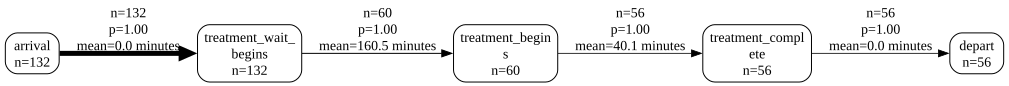

In [7]:
single_run.generate_dfg()

We can generate a different type of graph, passing in any arguments accepted by the relevant function. 

The accepted arguments can be found in the following places:

- Graphviz outputs: [here](../../reference/process_mapping.dfg_to_graphviz.qmd)
- Jupyter cytoscape outputs: [here](../../reference/process_mapping.dfg_to_cytoscape.qmd)
- Streamlit cytoscape outputs: [here](../../reference/process_mapping.dfg_to_cytoscape_streamlit.qmd)

In [8]:
single_run.generate_dfg(output_format="cytoscape-jupyter", spacing_factor=2)

Box(children=(CytoscapeWidget(cytoscape_layout={'name': 'dagre', 'directed': True, 'animate': True, 'randomize…

## Example 2 - A simple linear pathway - Without EventLogger, or for fine control over the DFG functions

First, we will need some extra imports. 

In [9]:
from vidigi.process_mapping import add_sim_timestamp, discover_dfg, dfg_to_graphviz, dfg_to_cytoscape

First, let's read in an event log. This is a standard vidigi event log created with the EventLogger class, with the dataframe saved as a csv for easy portability.

In [10]:
event_log = pd.read_csv("sample_event_log_10_day_10_run.csv")


**IMPORTANT** - we must filter any event log down to just a single run! 

If we don't, we'll get very odd behaviour because the entity IDs are reused across runs, and as entities will arrive at different points or take different paths in different runs, it will start to look like they've moved back and forth between different stages. 

Alternatively, you could create a new entity ID column where it takes account of the run number as well, and pass this through when we use the `discover_dfg()` vidigi function. 

In [11]:
event_log_single = event_log[event_log["run"]==1]

event_log_single.head()

,entity_id,pathway,event_type,event,time,resource_id,run
9969,1,Simplest,arrival_departure,arrival,0.000000,NaN,1
9970,1,Simplest,queue,treatment_wait_begins,0.000000,NaN,1
9971,1,Simplest,resource_use,treatment_begins,0.000000,1.0,1
9972,2,Simplest,arrival_departure,arrival,12.021043,NaN,1
9973,2,Simplest,queue,treatment_wait_begins,12.021043,NaN,1


:::{.callout-note}
Note that we could also do this for any situations where we want fine-grained control over the use of the individual DFG-creation functions, event if we have used EventLogger. 

In that case, we'd just get the event log in a pandas dataframe format using `event_log = my_event_logger_object.to_dataframe()`

The EventLogger object will already only contain a single run. If you are using TrialLogger, make sure you filter to a single run, as mentioned above. 
:::

Before we can pass this to our DFG functions, we need to add a timestamp column. 

This is because the functions are designed to work regardless of the unit of time you've used for your simulation - but it's a lot easier if we encode that at the beginning of the process, and allows the dfg to calculate various summary statistics.

The defaults for column names reflect vidigi's EventLogger default, so if we've used EventLogger, we won't need to specify column names here. 

If we have a simulation where we don't really have a date in mind - for example, a simulation that shows no seasonality across the year - then we can leave the `sim_start` parameter blank, and it will choose a dummy date of 12am on the 1st January, 2000. This won't be displayed anywhere in the later visualisations, so you don't have to worry too much about it! 

In [12]:
df_timestamp = add_sim_timestamp(event_log_single, time_unit="minutes")
df_timestamp.head()

,entity_id,pathway,event_type,event,time,resource_id,run,timestamp
9969,1,Simplest,arrival_departure,arrival,0.000000,NaN,1,2000-01-01 00:00:00.000000000
9970,1,Simplest,queue,treatment_wait_begins,0.000000,NaN,1,2000-01-01 00:00:00.000000000
9971,1,Simplest,resource_use,treatment_begins,0.000000,1.0,1,2000-01-01 00:00:00.000000000
9972,2,Simplest,arrival_departure,arrival,12.021043,NaN,1,2000-01-01 00:12:01.262581188
9973,2,Simplest,queue,treatment_wait_begins,12.021043,NaN,1,2000-01-01 00:12:01.262581188


Now we can use the `discover_dfg` function to turn the event log into the format required by the various static and interactive visualisation functions. 

In [13]:
nodes, edges = discover_dfg(df_timestamp)

Let's explore what our nodes look like. 

In [14]:
nodes

,activity,count
0,arrival,2855
1,depart,1441
2,treatment_begins,1445
3,treatment_complete,1441
4,treatment_wait_begins,2855


The edges dataframe then calculates the frequency of various transitions between nodes, the probability of each - here 1.0 as there are no branching steps - and various time-based metrics for each transition.

In [15]:
edges

,source,target,frequency,mean_time,median_time,max_time,min_time,standard_deviation_time,probability
0,arrival,treatment_wait_begins,2855,0.000000,0.000000,0.000000,0.000000,0.000000,1.0
1,treatment_begins,treatment_complete,1441,39.887907,39.709881,58.965050,25.199957,4.957233,1.0
2,treatment_complete,depart,1441,0.000000,0.000000,0.000000,0.000000,0.000000,1.0
3,treatment_wait_begins,treatment_begins,1445,3567.342893,3512.794222,7102.475786,0.000000,2040.848449,1.0


Finally, we can display the output. 

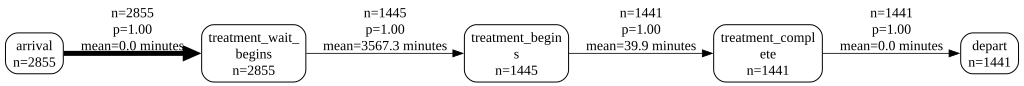

In [16]:
dfg_to_graphviz(
    nodes,
    edges,
)

By default, it will display the mean time between steps. We could instead ask for the median: 

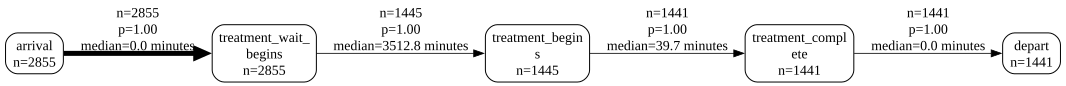

In [17]:
dfg_to_graphviz(
    nodes,
    edges,
    time_metric="median"
)

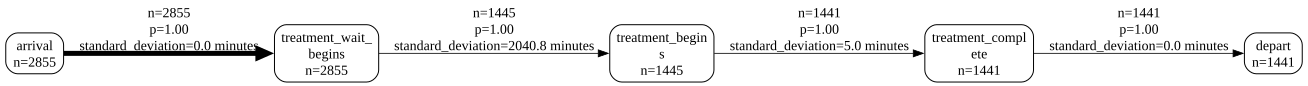

In [18]:
dfg_to_graphviz(
    nodes,
    edges,
    time_metric="standard_deviation"
)

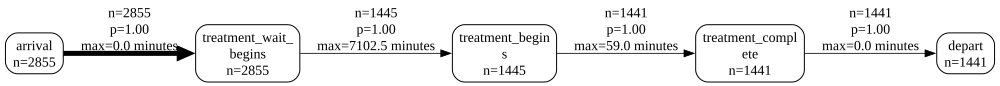

In [19]:
dfg_to_graphviz(
    nodes,
    edges,
    time_metric="max"
)

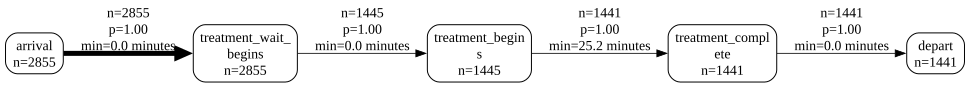

In [20]:
dfg_to_graphviz(
    nodes,
    edges,
    time_metric="min"
)

# A more complex example - stroke dataset - without EventLogger

Again, make sure we've imported the relevant functions. 

In [21]:
from vidigi.process_mapping import add_sim_timestamp, discover_dfg, dfg_to_graphviz, dfg_to_cytoscape

Let's do the same for a more complex example - a stroke ward with multiple branching pathways and patient types.

In [22]:
stroke_df = pd.read_csv("event_log_stroke.csv")
stroke_df.head()

,Unnamed: 0,id,patient_diagnosis_type,thrombolysis,admission_avoidance,advanced_ct_pathway,arrived_ooh,event,time,event_type,resource_id
0,0,1,I,True,False,True,True,clock_start,0.000000,arrival_departure,NaN
1,1,2,I,True,False,True,True,clock_start,415.319713,arrival_departure,NaN
2,2,3,TIA,False,True,True,False,clock_start,480.000000,arrival_departure,NaN
3,3,4,I,True,False,True,False,clock_start,481.157251,arrival_departure,NaN
4,4,5,I,True,False,True,False,clock_start,898.765362,arrival_departure,NaN


:::{.callout-note}
Again, note that we could also do this for any situations where we want fine-grained control over the use of the individual DFG-creation functions, event if we have used EventLogger. 

In that case, we'd just get the event log in a pandas dataframe format using `event_log = my_event_logger_object.to_dataframe()`

The EventLogger object will already only contain a single run. If you are using TrialLogger, make sure you filter to a single run, as mentioned above. 
:::

Let's tidy it up a bit!

The event names use underscores, which won't wrap onto new lines, so we'll replace those with spaces. We can also remove _time everywhere it appears, as in this case it's not adding anything useful. 

In [23]:
stroke_df["event"] = stroke_df["event"].apply(lambda x: x.replace("_time","").replace("_", " "))

Again, we'll add our timestamp, then get our nodes and edges. 

In [24]:
stroke_df_timestamp = add_sim_timestamp(stroke_df)

nodes, edges = discover_dfg(stroke_df_timestamp, case_col="id")

nodes

,activity,count
0,clock start,3490
1,ct or ctp scan end,3490
2,ct or ctp scan start,3490
3,exit,3490
4,nurse q start,3490
5,nurse triage end,3490
6,nurse triage start,3490
7,sdec admit,1556
8,sdec discharge,1556
9,ward admit,2121


In [25]:
edges

,source,target,frequency,mean_time,median_time,max_time,min_time,standard_deviation_time,probability
0,clock start,nurse q start,3490,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
1,ct or ctp scan end,exit,566,0.000000,0.000000,0.000000,0.000000,0.000000,0.162178
2,ct or ctp scan end,sdec admit,1556,0.104592,0.000000,79.141723,0.000000,2.734817,0.445845
3,ct or ctp scan end,ward q start,1368,0.000000,0.000000,0.000000,0.000000,0.000000,0.391977
4,ct or ctp scan start,ct or ctp scan end,3490,19.622976,13.640368,213.116992,0.009150,19.991279,1.000000
5,nurse q start,nurse triage start,3490,1.315213,0.000000,212.852738,0.000000,10.424784,1.000000
6,nurse triage end,ct or ctp scan start,3490,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
7,nurse triage start,nurse triage end,3490,58.501266,41.104481,430.000987,0.017171,58.650424,1.000000
8,sdec admit,sdec discharge,1556,240.563909,157.352706,2483.017874,0.208562,252.735487,1.000000
9,sdec discharge,exit,803,0.000000,0.000000,0.000000,0.000000,0.000000,0.516067


Let's see what this looks like. 

We'll also make use of a couple of extra parameters, filtering out any very infrequent paths. 

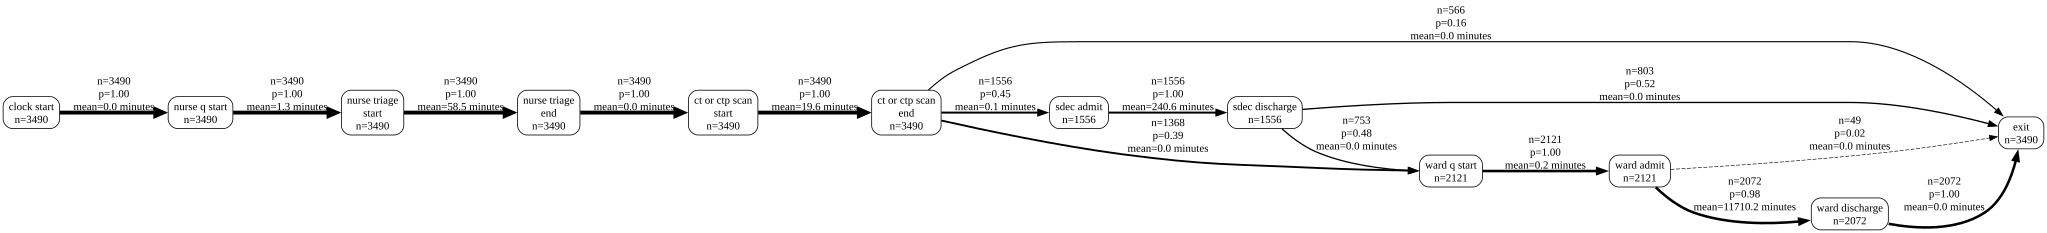

In [26]:
g = dfg_to_graphviz(
    nodes,
    edges,
    min_frequency=5
)

g

Let's take a quick look at what our output actually is. 

In [27]:
type(g)

graphviz.graphs.Digraph

It's a graphviz Digraph object, which we could continue to modify if we wanted to. 

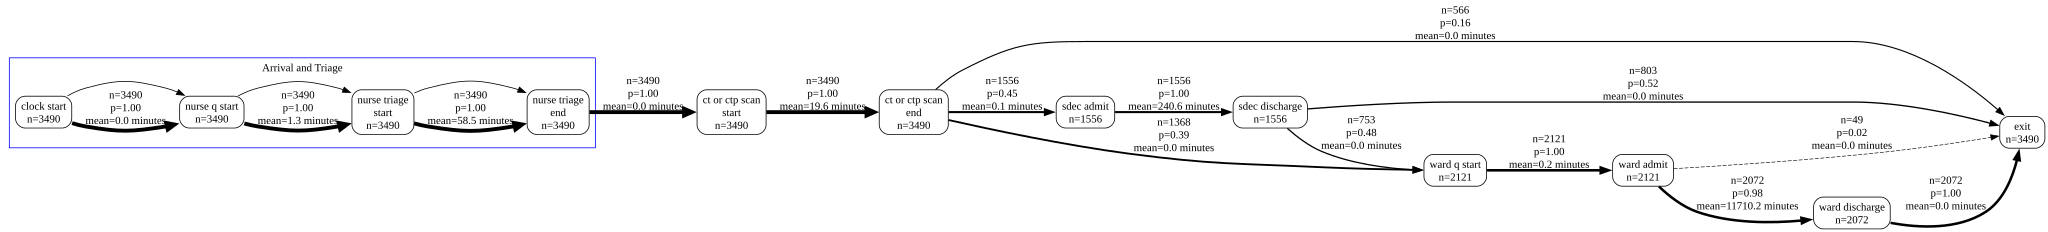

In [28]:
with g.subgraph(name='cluster_0') as c:
    c.attr(color='blue')
    c.node_attr['style'] = 'filled'
    # Note that we will need to include the newline indicator when filtering; we can work out where this is by visually observing
    # the node labels in the orignal diagram
    c.edges([('clock start', 'nurse q start'), ('nurse q start', 'nurse triage\nstart'), ('nurse triage\nstart', 'nurse triage\nend')])
    c.attr(label='Arrival and Triage')

g

We can also output to an image type - but note it will output as a series of bytes that will need to be converted into an image in some other way depending on your intended use.

In [29]:
g_png = dfg_to_graphviz(
    nodes,
    edges,
    min_frequency=5,
    return_image=True,
    format="png"
)

type(g_png)

bytes

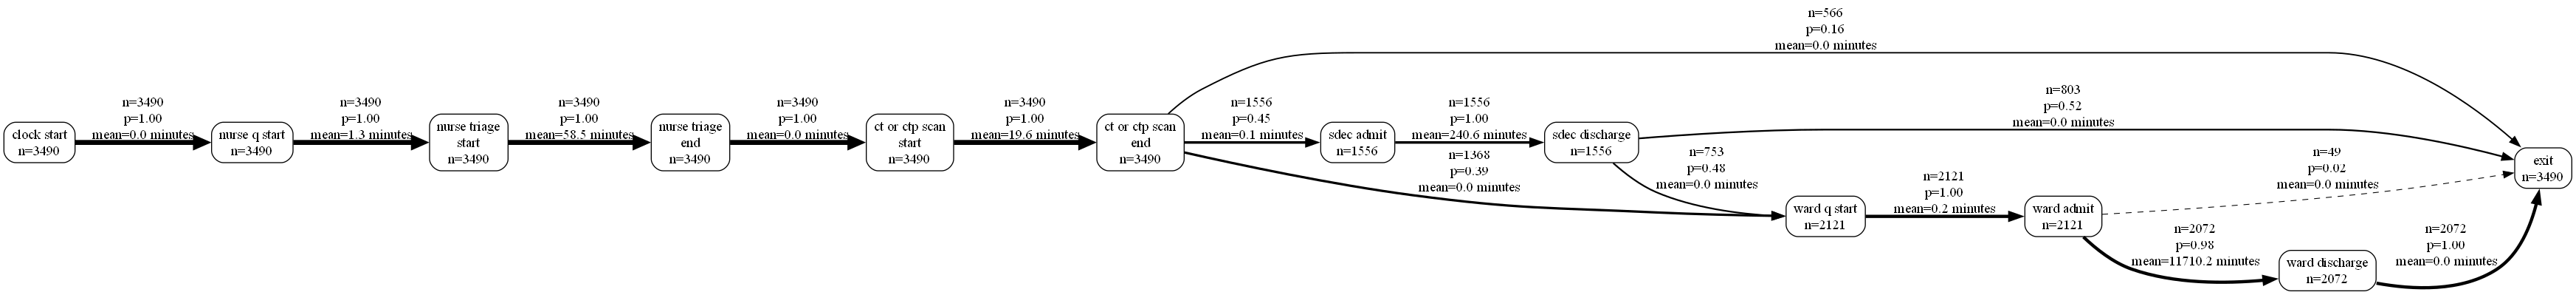

In [30]:
from IPython.display import Image

Image(g_png)

We can also change the orientation of the output. 

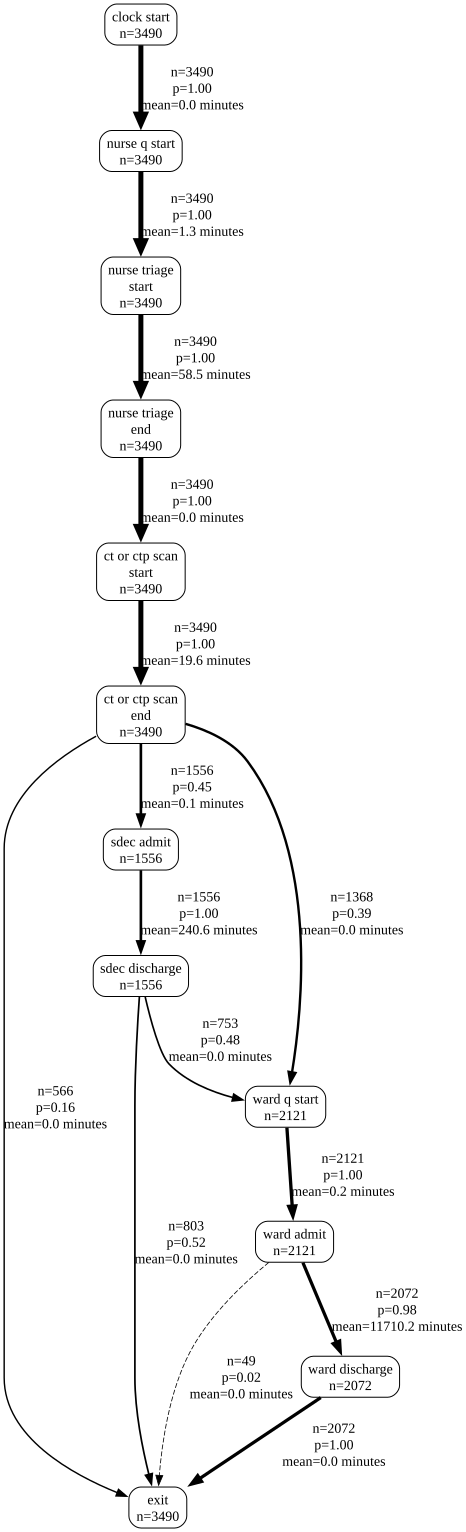

In [31]:
dfg_to_graphviz(
    nodes,
    edges,
    min_frequency=5,
    direction="TD"
)

While the early parts of the process are easy to interpret in minutes, it's hard to interpret the ward stay durations, which are much longer. 

We might actually want to split these into two separate graphs by filtering the node and edges table. 

For now, though, we're going to rediscover our dfg using a unit of days, recalculate our timestamp and node/edge dataframes, and visualise this again. Note where 'minutes' has changed to 'days'. 

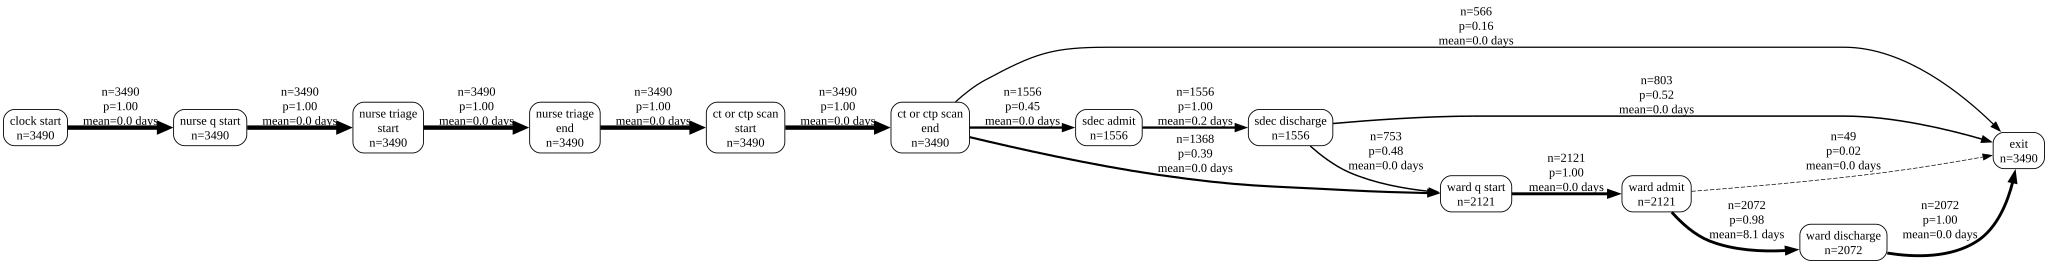

In [32]:
nodes, edges = discover_dfg(stroke_df_timestamp, case_col="id", time_unit="days")

dfg_to_graphviz(
    nodes,
    edges,
    min_frequency=5,
    time_unit="days",
)


### Looping through graphviz outputs

While a lot of value can be obtained from just checking that your model is behaving as expected, you can get even more out of these outputs by faceting by different elements. 

For example, here we expect patients with different stroke types to have different lengths of stay. 

We need to import the `display` function from `IPython.display` and explicitly call this to ensure it's included. 

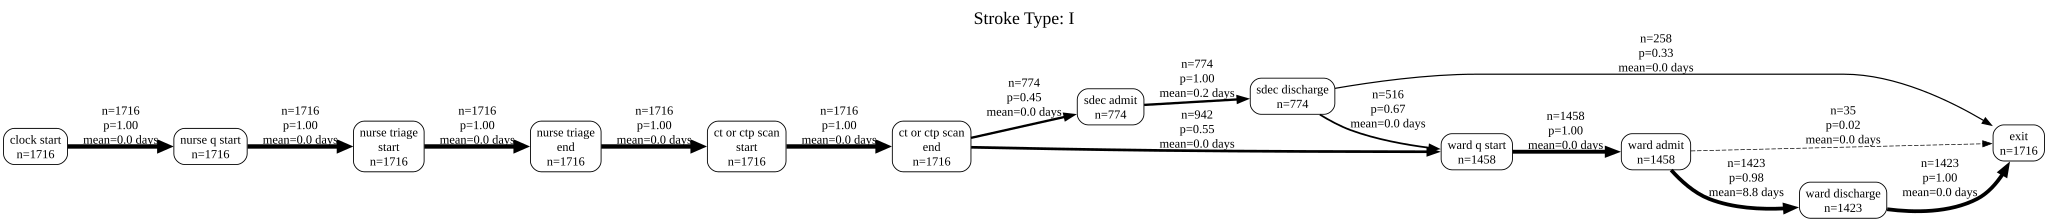

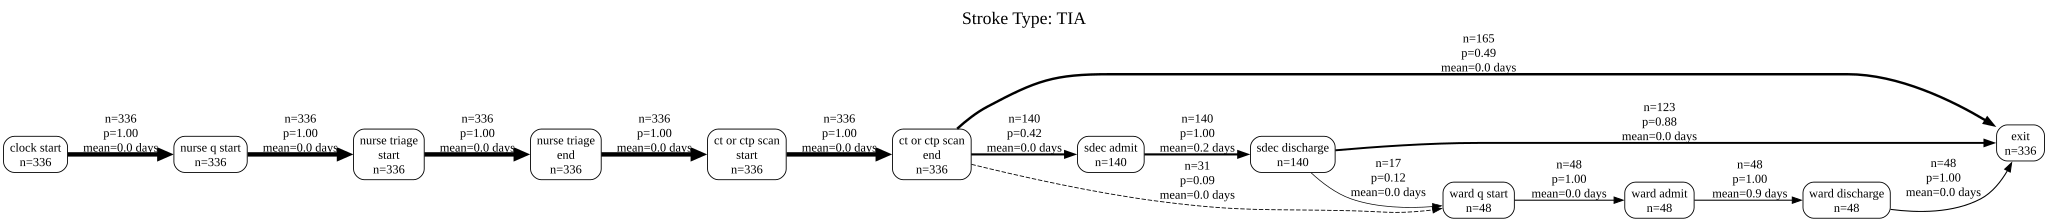

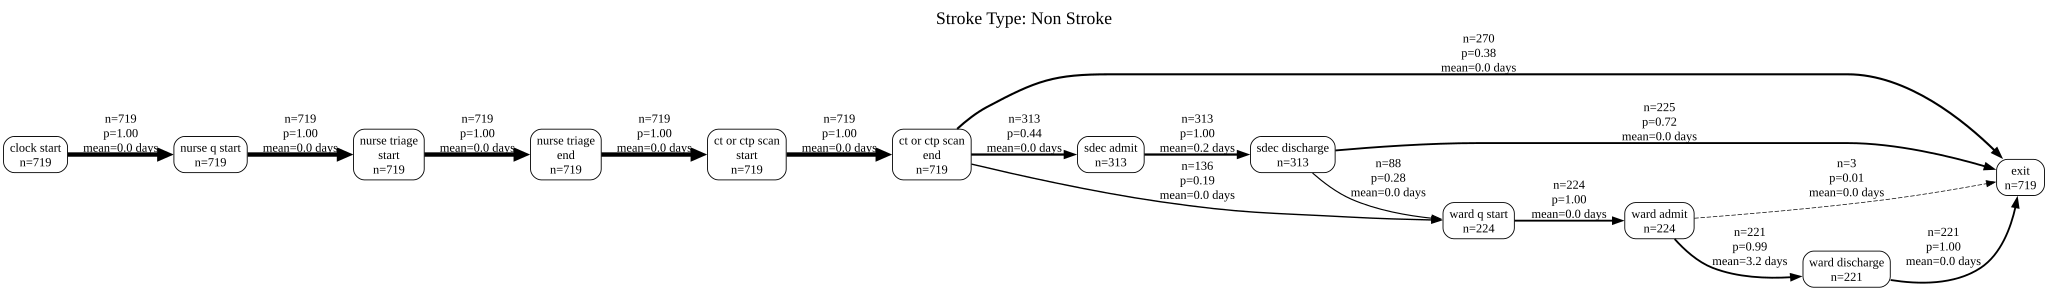

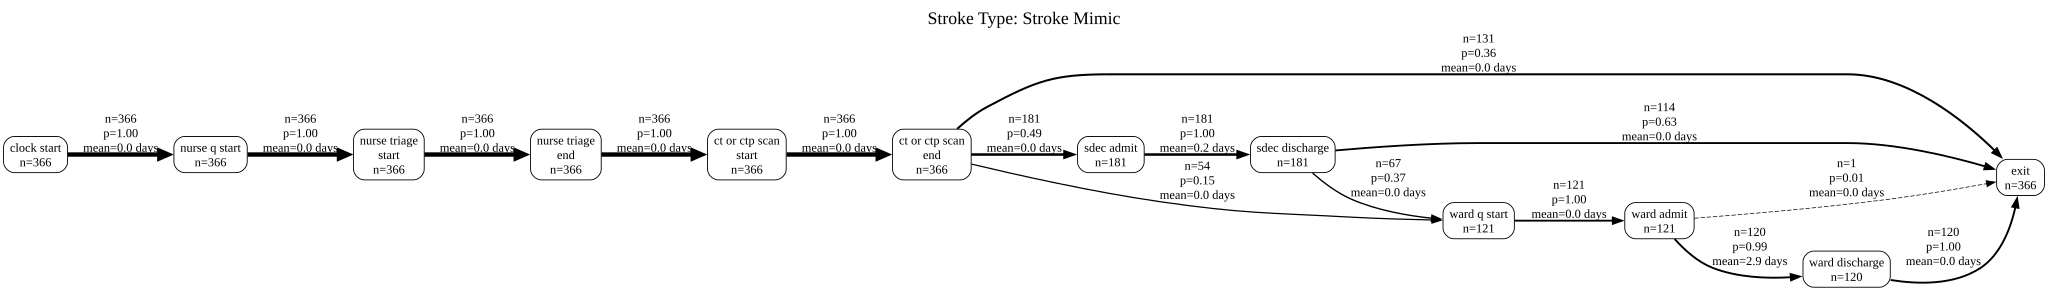

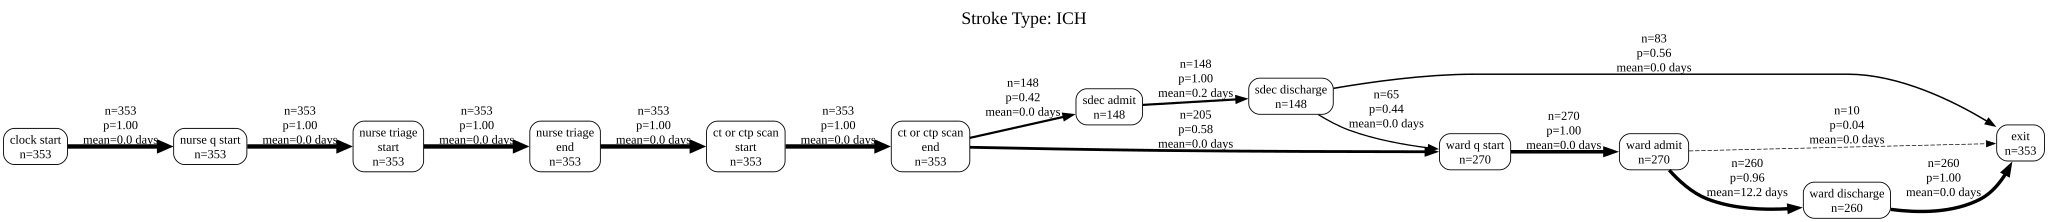

In [33]:
from IPython.display import display

for i in stroke_df_timestamp["patient_diagnosis_type"].unique():

    df = stroke_df_timestamp[stroke_df_timestamp["patient_diagnosis_type"]==i]

    nodes, edges = discover_dfg(df, case_col="id", time_unit="days")

    display(dfg_to_graphviz(
        nodes,
        edges,
        time_unit="days",
        title=f"Stroke Type: {i}"
    ))

We could do what we talked about earlier and try filtering the nodes and edges. 

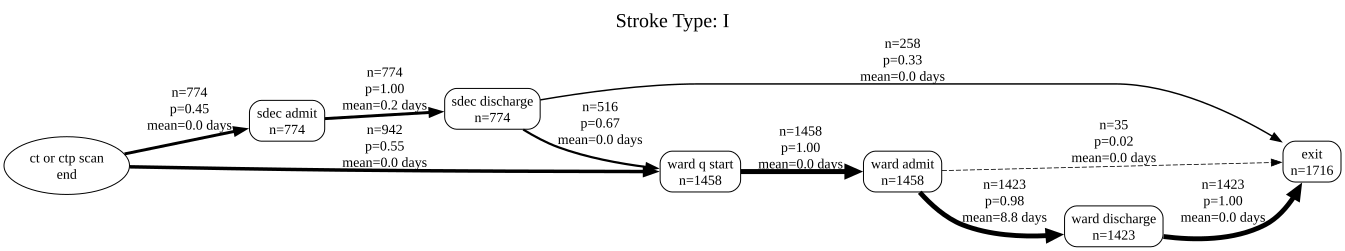

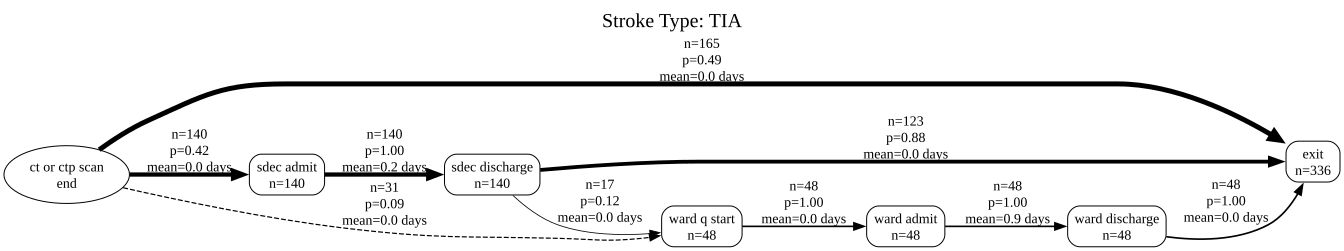

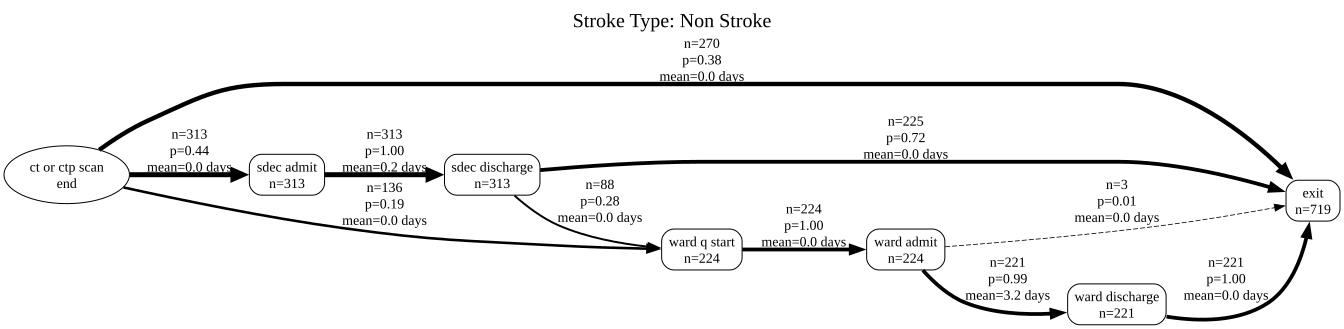

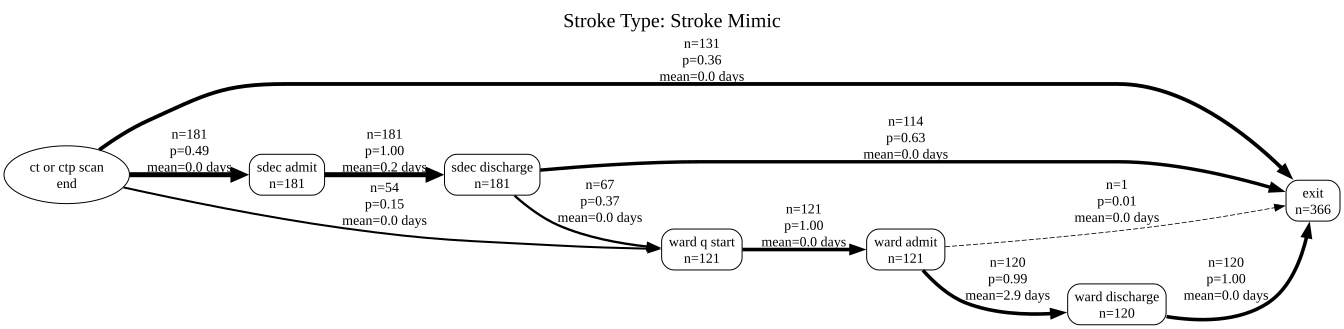

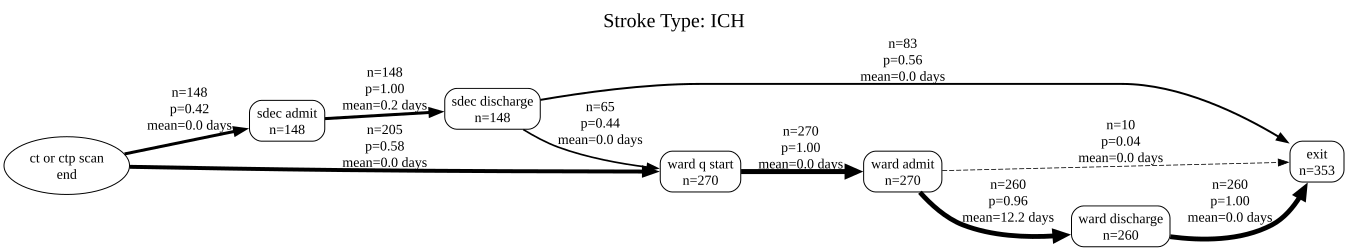

In [34]:
from IPython.display import display

for i in stroke_df_timestamp["patient_diagnosis_type"].unique():

    df = stroke_df_timestamp[stroke_df_timestamp["patient_diagnosis_type"]==i]

    nodes, edges = discover_dfg(df, case_col="id", time_unit="days")

    # Remember that we will need to include the newline indicator when filtering; we can work out where this is by visually observing
    # the node labels in the orignal diagram
    steps_to_include = ["ct or ctp scan\nend", "sdec admit", "sdec discharge", "ward q start", "ward admit", "ward discharge", "exit"]

    nodes = nodes[nodes["activity"].isin(steps_to_include)]

    edges = edges[(edges["source"].isin(steps_to_include)) |
                  (edges["target"].isin(steps_to_include))]

    display(dfg_to_graphviz(
        nodes,
        edges,
        time_unit="days",
        title=f"Stroke Type: {i}"
    ))

We could check out the maximum durations too. 

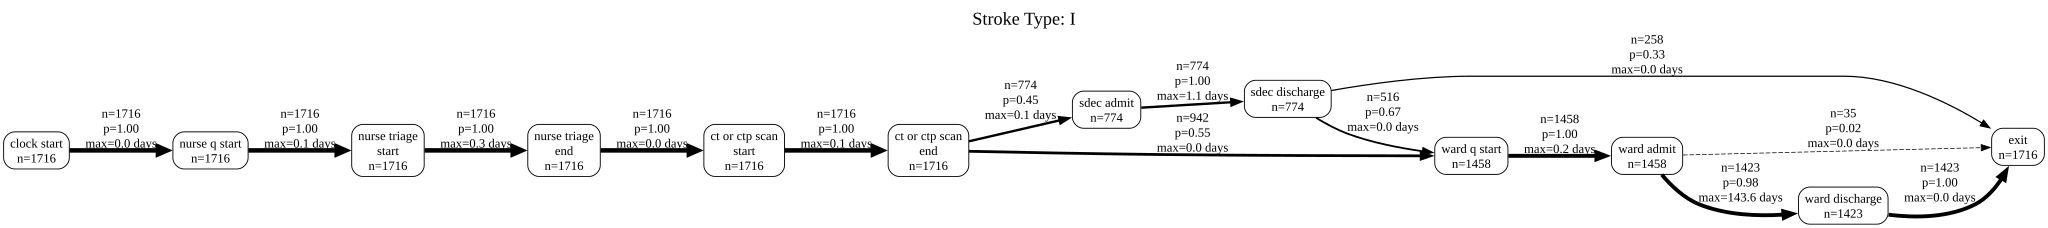

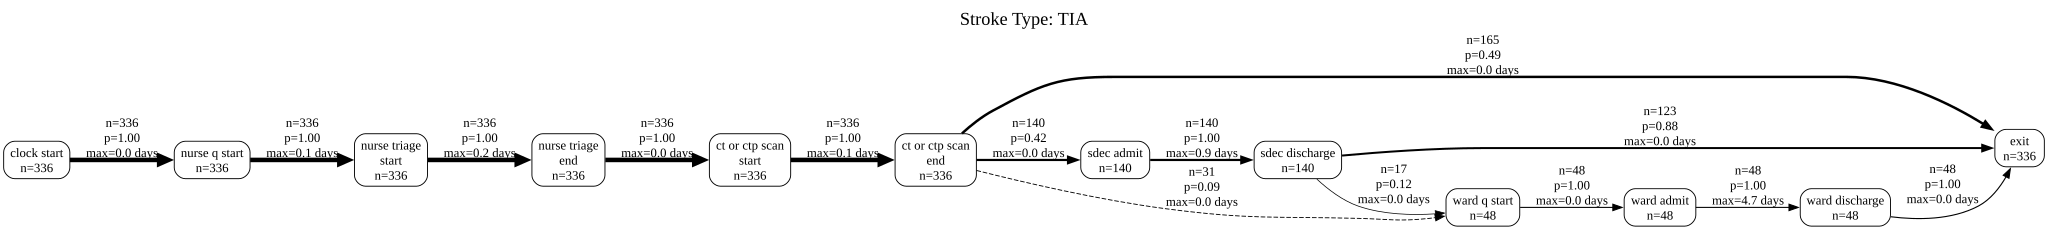

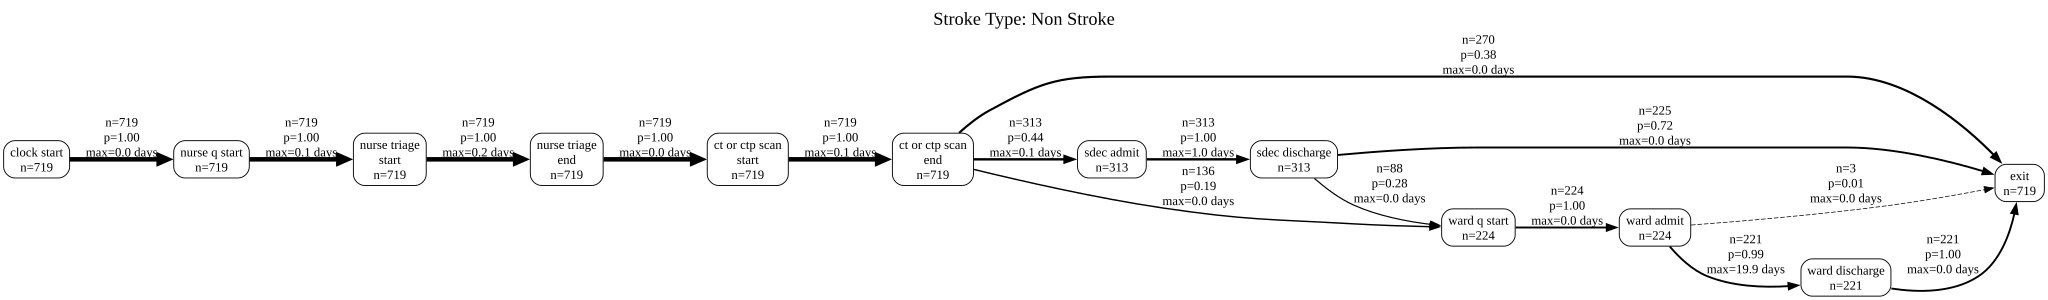

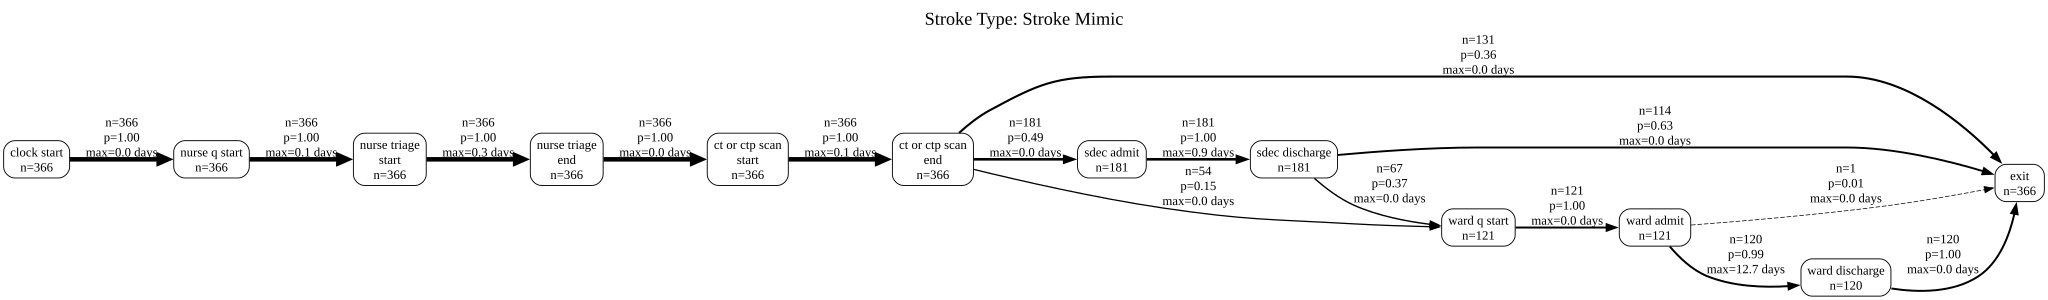

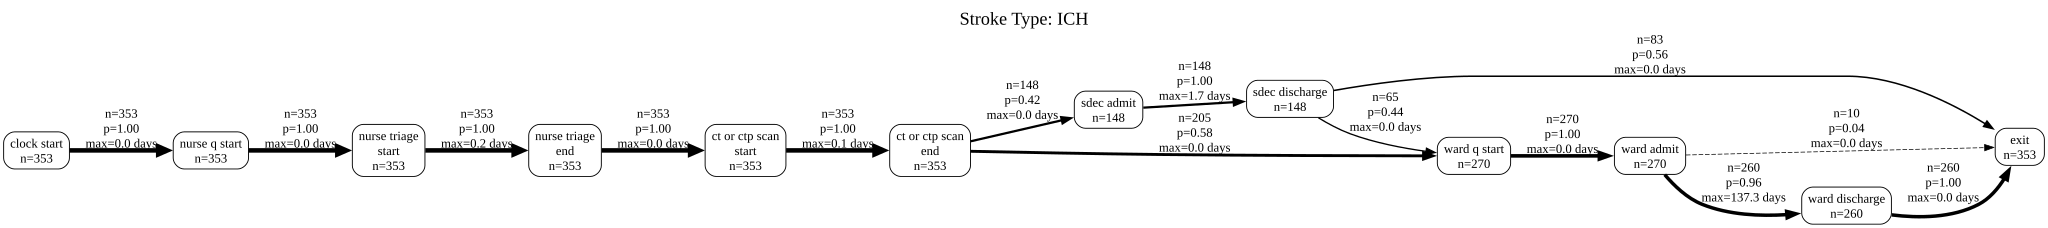

In [35]:
for i in stroke_df_timestamp["patient_diagnosis_type"].unique():

    df = stroke_df_timestamp[stroke_df_timestamp["patient_diagnosis_type"]==i]

    nodes, edges = discover_dfg(df, case_col="id", time_unit="days")

    display(dfg_to_graphviz(
        nodes,
        edges,
        time_unit="days",
        title=f"Stroke Type: {i}",
        time_metric="max"
    ))

### Interactive outputs

Finally, let's take a look at an interactive output. 

Here, we pass in the same nodes and edges. However, we need to choose a layout; 'dagre' is often the best option for getting something that looks similar to graphviz. 

In [36]:
nodes, edges = discover_dfg(stroke_df_timestamp, case_col="id", timestamp_col="timestamp", time_unit="days")

op = dfg_to_cytoscape(
    nodes,
    edges,
    layout_name='dagre',
    layout_orientation="LR",
    spacing_factor=1.5,
    width=1400,
    time_unit="days")


display(op)

Box(children=(CytoscapeWidget(cytoscape_layout={'name': 'dagre', 'directed': True, 'animate': True, 'randomize…

You can also try this out in the following Streamlit app. 

```{=html}
<iframe width='780' height='500' src='https://vidigi-dfg-demo.streamlit.app/?embed=true' title='Demo app'></iframe>
```